# 07 — External Validation Across Three Models

**Manuscript section:** Results §9 — *External validation: shared outliers are biologically essential, architecture-specific outliers are not*

**Manuscript figures:** Fig 5a–e, Supplementary Figure S5

Validates geometric outliers against five independent datasets: gnomAD constraint,
DepMap CRISPR essentiality, ClinVar disease associations, IMPC mouse phenotypes,
and Replogle perturb-seq effect sizes. Also computes consensus anomaly scores.

**Data inputs:**
- `data/cross_model_comparison.csv`, `data/three_model_comparison.csv`
- `data/external_validation_results.csv`, `data/sf_external_validation_results.csv`
- `data/cross_model_external_validation.csv`


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*is_categorical_dtype.*')

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import fisher_exact, spearmanr

import glitch_style
importlib.reload(glitch_style)
from glitch_style import CONTROL_COLOR, FIG_DOUBLE, FIG_SINGLE, GLITCH_COLOR, NEUTRAL_COLOR, apply_style, save_fig

# ── Verify required inputs exist ──
from pathlib import Path
assert Path('data/cross_model_comparison.csv').exists(), "Missing data/cross_model_comparison.csv — run P03 first"
assert Path('data/cross_model_external_validation.csv').exists(), "Missing data/cross_model_external_validation.csv — run P05 first"

In [2]:
cm = pd.read_csv('data/cross_model_comparison.csv')

# Merge IMPC phenotype counts (stored separately in external cache)
gea = pd.read_csv('data/gene_embedding_annotated.csv')[['gene', 'ensembl_id']].drop_duplicates()
cm = cm.merge(gea, on='gene', how='left')
impc = pd.read_csv('data/external/impc_phenotype_counts.csv')
# IMPC uses gene symbol, not ensembl_id
impc_merge_col = 'ensembl_id' if 'ensembl_id' in impc.columns else 'gene'
cm = cm.merge(impc[['n_phenotypes', impc_merge_col]].drop_duplicates(impc_merge_col),
              on=impc_merge_col, how='left', suffixes=('_old', ''))
# Use merged column, drop the empty original
if 'n_phenotypes_old' in cm.columns:
    cm.drop(columns=['n_phenotypes_old'], inplace=True)

# Load Replogle K562 perturb-seq leverage scores
rep = pd.read_csv('data/external/1-s2/TabA_K562_day8_summary_stat-Table 1.csv')
rep.columns = rep.columns.str.strip()
rep['ensembl_id'] = rep['genetic perturbation'].str.extract(r'(ENSG\d+)')[0]
rep = rep.dropna(subset=['ensembl_id', 'mean leverage score'])

# Load ClinVar data from cross_model_external_validation (has n_pathogenic + disease_gene)
cmv = pd.read_csv('data/cross_model_external_validation.csv')

# Load perturbation sensitivity for Replogle correlation
perturb = pd.read_csv('data/perturbation_sensitivity.csv')

print(f'Cross-model data: {len(cm):,} genes')
print(f'Outlier sets: {cm["outlier_set"].value_counts().to_dict()}')
print(f'IMPC phenotypes available: {cm["n_phenotypes"].notna().sum():,} genes')
print(f'Replogle K562 leverage scores: {len(rep):,} perturbations')
print(f'Perturbation sensitivity genes: {len(perturb)}')

Cross-model data: 18,915 genes
Outlier sets: {'neither': 18344, 'GF-only': 309, 'SF-only': 153, 'GF∩scGPT': 71, 'scGPT-only': 30, 'GF∩SF': 7, 'All three': 1}
IMPC phenotypes available: 8,020 genes
Replogle K562 leverage scores: 10,656 perturbations
Perturbation sensitivity genes: 95


## Fig 5a — pLI > 0.9 enrichment forest plot

GF-only: n=265, pLI>0.9=93 (35.1%), OR=2.6 [2.0–3.3]
scGPT-only: n=24, pLI>0.9=14 (58.3%), OR=6.6 [3.0–14.6]
GF∩scGPT: n=57, pLI>0.9=41 (71.9%), OR=12.0 [6.8–21.2]
SF-only: n=132, pLI>0.9=20 (15.2%), OR=0.9 [0.5–1.4]


Saved: figs/Fig5a_pli_enrichment_forest.pdf, figs/Fig5a_pli_enrichment_forest.png


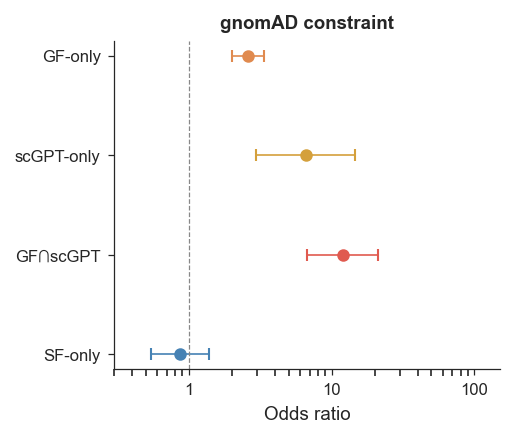

In [3]:
apply_style()

cm_pli = cm.dropna(subset=['pLI']).copy()
cm_pli['high_pli'] = cm_pli['pLI'] > 0.9

bg = cm_pli[cm_pli['outlier_set'] == 'neither']
bg_pos, bg_neg = int(bg['high_pli'].sum()), len(bg) - int(bg['high_pli'].sum())

# Order: single-model groups first, then their intersection, then SF
# Top-to-bottom in the plot = last-to-first in the list (matplotlib y-axis)
categories = ['GF-only', 'scGPT-only', 'GF∩scGPT', 'SF-only']
cat_colors = ['#E08A4F', '#D4A03C', GLITCH_COLOR, CONTROL_COLOR]

fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')
y_pos = np.arange(len(categories))[::-1]

for i, cat in enumerate(categories):
    sub = cm_pli[cm_pli['outlier_set'] == cat]
    a = int(sub['high_pli'].sum())
    b = len(sub) - a
    # Haldane-corrected OR + CI
    aa, bb, cc, dd = a + 0.5, b + 0.5, bg_pos + 0.5, bg_neg + 0.5
    OR = (aa * dd) / (bb * cc)
    se = np.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
    ci_lo, ci_hi = np.exp(np.log(OR) - 1.96*se), np.exp(np.log(OR) + 1.96*se)

    ax.errorbar(OR, y_pos[i], xerr=[[OR - ci_lo], [ci_hi - OR]],
                fmt='o', color=cat_colors[i], markersize=5, capsize=3, linewidth=0.8)
    print(f'{cat}: n={len(sub)}, pLI>0.9={a} ({a/len(sub)*100:.1f}%), OR={OR:.1f} [{ci_lo:.1f}–{ci_hi:.1f}]')

ax.axvline(1.0, color=NEUTRAL_COLOR, linestyle='--', linewidth=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(categories)
ax.set_xlabel('Odds ratio')
ax.set_title('gnomAD constraint', fontsize=9, fontweight='bold')
ax.set_xscale('log')
ax.set_xlim(0.3, 150)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())


sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig5a_pli_enrichment_forest')
plt.show()


## Fig 5b — DepMap + IMPC with three-model groups

/var/folders/j6/6pz4l2t10238hsq7sl5n5qww0000gn/T/ipykernel_78562/4144468349.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(group_order, rotation=30, ha='right')
/var/folders/j6/6pz4l2t10238hsq7sl5n5qww0000gn/T/ipykernel_78562/4144468349.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(group_order, rotation=30, ha='right')


Saved: figs/Fig5b_depmap_impc_3model.pdf, figs/Fig5b_depmap_impc_3model.png


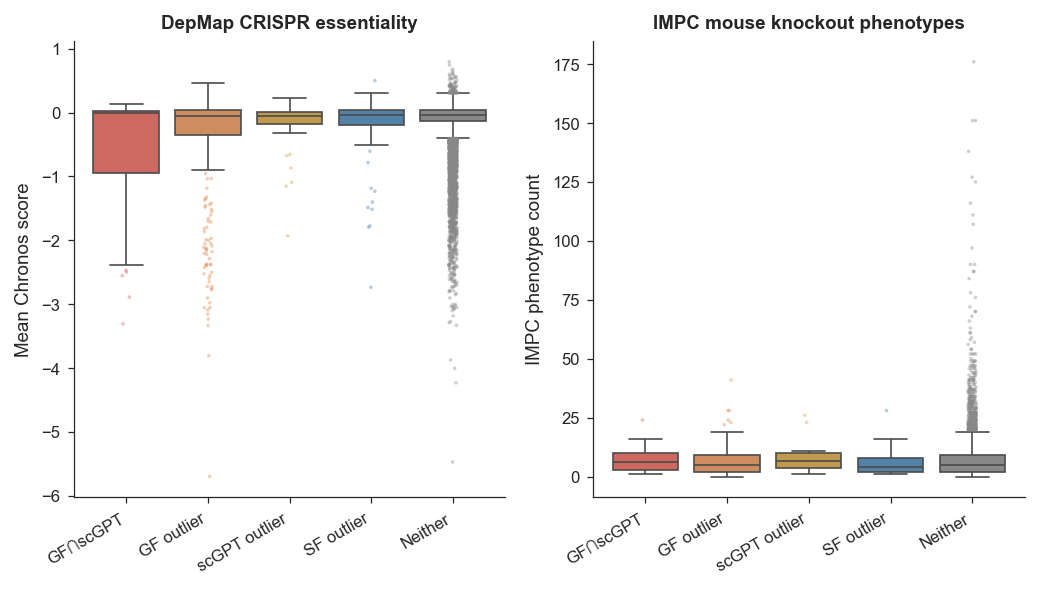

In [4]:
cm['plot_group'] = 'Neither'
cm.loc[cm['is_gf_outlier'] & ~cm['is_sc_outlier'] & ~cm['is_sf_outlier'], 'plot_group'] = 'GF outlier'
cm.loc[cm['is_sc_outlier'] & ~cm['is_gf_outlier'] & ~cm['is_sf_outlier'], 'plot_group'] = 'scGPT outlier'
cm.loc[cm['is_sf_outlier'] & ~cm['is_gf_outlier'] & ~cm['is_sc_outlier'], 'plot_group'] = 'SF outlier'
cm.loc[cm['is_gf_outlier'] & cm['is_sc_outlier'], 'plot_group'] = 'GF∩scGPT'

group_order = ['GF∩scGPT', 'GF outlier', 'scGPT outlier', 'SF outlier', 'Neither']
pal = dict(zip(group_order, [GLITCH_COLOR, '#E08A4F', '#D4A03C', CONTROL_COLOR, NEUTRAL_COLOR]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIG_DOUBLE, facecolor='white')

# Helper: draw boxplot then overlay outlier points beyond whiskers
def boxplot_with_fliers(data, x, y, order, palette, ax, flier_size=3, flier_alpha=0.4):
    sns.boxplot(data=data, x=x, y=y, order=order, palette=palette, ax=ax,
                showfliers=False, linewidth=0.8)
    # Manually plot points beyond 1.5*IQR whiskers
    for i, grp in enumerate(order):
        vals = data.loc[data[x] == grp, y].dropna().values
        if len(vals) == 0:
            continue
        q1, q3 = np.percentile(vals, [25, 75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = vals[(vals < lo) | (vals > hi)]
        if len(outliers) > 0:
            ax.scatter(np.full_like(outliers, i) + np.random.uniform(-0.05, 0.05, len(outliers)),
                       outliers, s=flier_size, alpha=flier_alpha, color=palette[grp],
                       edgecolors='none', zorder=3, rasterized=True)

boxplot_with_fliers(cm.dropna(subset=['mean_dep']), 'plot_group', 'mean_dep',
                    group_order, pal, ax1)
ax1.set_xlabel('')
ax1.set_ylabel('Mean Chronos score')
ax1.set_title('DepMap CRISPR essentiality', fontsize=9, fontweight='bold')
ax1.set_xticklabels(group_order, rotation=30, ha='right')

boxplot_with_fliers(cm.dropna(subset=['n_phenotypes']), 'plot_group', 'n_phenotypes',
                    group_order, pal, ax2)
ax2.set_xlabel('')
ax2.set_ylabel('IMPC phenotype count')
ax2.set_title('IMPC mouse knockout phenotypes', fontsize=9, fontweight='bold')
ax2.set_xticklabels(group_order, rotation=30, ha='right')

sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig5b_depmap_impc_3model')
plt.show()

## Fig 5c — ClinVar disease association

Shared outliers: 53/71 disease-associated (74.6%)
Background:      8023/18344 disease-associated (43.7%)
Fisher p = 2.03e-07, Haldane OR = 3.7 [2.2–6.3]


Saved: figs/Fig5c_clinvar_enrichment.pdf, figs/Fig5c_clinvar_enrichment.png


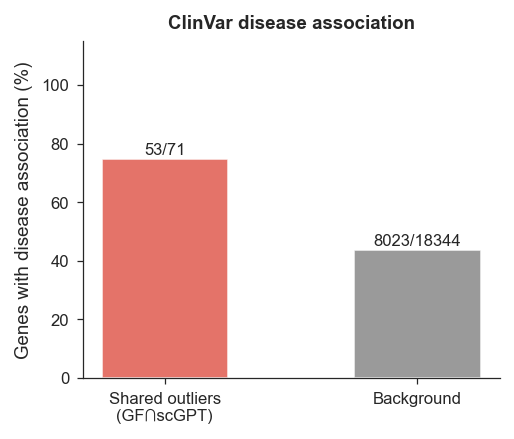

In [5]:
# Fig 5c: ClinVar disease association — shared outliers vs background
#
# ClinVar disease association: shared GF∩scGPT outliers vs background.
# Uses disease_gene flag from cross_model_external_validation.csv.
# Haldane–Anscombe corrected OR + 95% CI reported in manuscript.

# Build contingency from cross_model_external_validation
shared = cmv[cmv['outlier_set'] == 'GF∩scGPT']
controls = cmv[cmv['outlier_set'] == 'neither']

# disease_gene == True means ClinVar disease association present
shared_pos = int(shared['disease_gene'].sum())
shared_neg = len(shared) - shared_pos
ctrl_pos = int(controls['disease_gene'].sum())
ctrl_neg = len(controls) - ctrl_pos

print(f'Shared outliers: {shared_pos}/{len(shared)} disease-associated ({shared_pos/len(shared)*100:.1f}%)')
print(f'Background:      {ctrl_pos}/{len(controls)} disease-associated ({ctrl_pos/len(controls)*100:.1f}%)')

# Fisher exact test
OR_fisher, p_fisher = fisher_exact([[shared_pos, shared_neg], [ctrl_pos, ctrl_neg]])
# Haldane-Anscombe corrected OR + CI
aa, bb, cc, dd = shared_pos+0.5, shared_neg+0.5, ctrl_pos+0.5, ctrl_neg+0.5
OR_ha = (aa * dd) / (bb * cc)
se_ha = np.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
ci_lo, ci_hi = np.exp(np.log(OR_ha) - 1.96*se_ha), np.exp(np.log(OR_ha) + 1.96*se_ha)
print(f'Fisher p = {p_fisher:.2e}, Haldane OR = {OR_ha:.1f} [{ci_lo:.1f}–{ci_hi:.1f}]')

# Bar chart: proportion with disease association
fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')
categories = ['Shared outliers\n(GF∩scGPT)', 'Background']
proportions = [shared_pos / len(shared) * 100, ctrl_pos / len(controls) * 100]
counts_label = [f'{shared_pos}/{len(shared)}', f'{ctrl_pos}/{len(controls)}']
colors = [GLITCH_COLOR, NEUTRAL_COLOR]

bars = ax.bar(categories, proportions, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, label in zip(bars, counts_label):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            label, ha='center', fontsize=8)

ax.set_ylabel('Genes with disease association (%)')
ax.set_ylim(0, 115)
ax.set_title('ClinVar disease association', fontsize=9, fontweight='bold')

# Stats kept in caption, not on plot

sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig5c_clinvar_enrichment')
plt.show()


## Fig 5d — Replogle perturb-seq correlation

Matched genes: 32 (30 glitch, 2 control)
Spearman: ρ = 0.645, p = 6.85e-05


Saved: figs/Fig5d_replogle_correlation.pdf, figs/Fig5d_replogle_correlation.png


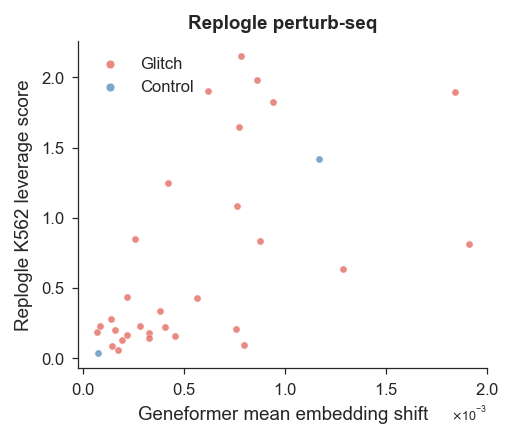

In [6]:
# Fig 5d: Replogle perturb-seq — Geneformer embedding shifts vs K562 leverage scores
# Caption: "Geneformer embedding shifts correlate with Replogle perturb-seq
# transcriptomic effect sizes (rho=0.645, p=6.85e-5)."

# Merge perturbation sensitivity with Replogle leverage
rep_merge = perturb.merge(rep[['ensembl_id', 'mean leverage score']], on='ensembl_id', how='inner')
print(f'Matched genes: {len(rep_merge)} ({(rep_merge["group"]=="glitch").sum()} glitch, '
      f'{(rep_merge["group"]=="control").sum()} control)')

rho, p = spearmanr(rep_merge['mean_shift'], rep_merge['mean leverage score'])
print(f'Spearman: ρ = {rho:.3f}, p = {p:.2e}')

fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')
for grp, color, label in [('glitch', GLITCH_COLOR, 'Glitch'), ('control', CONTROL_COLOR, 'Control')]:
    sub = rep_merge[rep_merge['group'] == grp]
    ax.scatter(sub['mean_shift'], sub['mean leverage score'], color=color, s=12, alpha=0.7,
               label=label, edgecolors='white', linewidth=0.3, zorder=3)

ax.set_xlabel('Geneformer mean embedding shift')
ax.set_ylabel('Replogle K562 leverage score')
ax.set_title('Replogle perturb-seq', fontsize=9, fontweight='bold')

# Fix x-axis: use scientific notation for small decimal values
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
ax.xaxis.get_offset_text().set_fontsize(6)

# Stats kept in caption, not on plot
ax.legend(markerscale=1.2)

sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig5d_replogle_correlation')
plt.show()


## Fig 5e — Consensus anomaly score vs IMPC phenotypes

Genes with IMPC data: 8020
GF alone vs IMPC:     ρ = 0.009, p = 4.10e-01
scGPT alone vs IMPC:  ρ = 0.087, p = 8.06e-15
SF alone vs IMPC:     ρ = 0.014, p = 2.07e-01
2-model consensus:    ρ = 0.057, p = 3.21e-07
3-model consensus:    ρ = 0.054, p = 1.45e-06
Saved: figs/Fig5e_consensus_impc.pdf, figs/Fig5e_consensus_impc.png


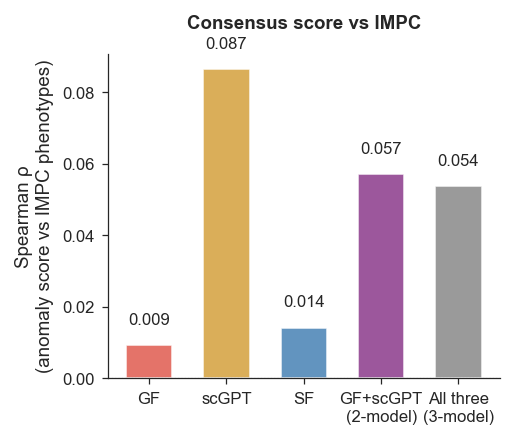

In [7]:
# Fig 5e: Consensus anomaly score — 2-model vs 3-model comparison against IMPC
# Caption: "A two-model (GF-scGPT) consensus outperforms either model alone on
# IMPC phenotype counts. Adding scFoundation does not improve prediction."

# IMPC is only available for a subset of genes — use those
cm_impc = cm.dropna(subset=['n_phenotypes']).copy()
print(f'Genes with IMPC data: {len(cm_impc)}')

# Compute correlations: individual models vs IMPC
rho_gf, p_gf = spearmanr(cm_impc['gf_anomaly_score'], cm_impc['n_phenotypes'])
rho_sc, p_sc = spearmanr(cm_impc['scgpt_anomaly'], cm_impc['n_phenotypes'])
rho_sf, p_sf = spearmanr(cm_impc['sf_anomaly'], cm_impc['n_phenotypes'])
rho_2m, p_2m = spearmanr(cm_impc['consensus_2m'], cm_impc['n_phenotypes'])
rho_3m, p_3m = spearmanr(cm_impc['consensus_3m'], cm_impc['n_phenotypes'])

print(f'GF alone vs IMPC:     ρ = {rho_gf:.3f}, p = {p_gf:.2e}')
print(f'scGPT alone vs IMPC:  ρ = {rho_sc:.3f}, p = {p_sc:.2e}')
print(f'SF alone vs IMPC:     ρ = {rho_sf:.3f}, p = {p_sf:.2e}')
print(f'2-model consensus:    ρ = {rho_2m:.3f}, p = {p_2m:.2e}')
print(f'3-model consensus:    ρ = {rho_3m:.3f}, p = {p_3m:.2e}')

# Bar chart of correlations
fig, ax = plt.subplots(figsize=FIG_SINGLE, facecolor='white')
labels = ['GF', 'scGPT', 'SF', 'GF+scGPT\n(2-model)', 'All three\n(3-model)']
rhos = [rho_gf, rho_sc, rho_sf, rho_2m, rho_3m]
colors = [GLITCH_COLOR, '#D4A03C', CONTROL_COLOR, '#8B3A8B', NEUTRAL_COLOR]

bars = ax.bar(labels, rhos, color=colors, alpha=0.85, edgecolor='white', width=0.6)
for bar, rho_val in zip(bars, rhos):
    ax.text(bar.get_x() + bar.get_width()/2, rho_val + 0.005 if rho_val >= 0 else rho_val - 0.015,
            f'{rho_val:.3f}', ha='center', fontsize=8, va='bottom')

ax.set_ylabel('Spearman ρ\n(anomaly score vs IMPC phenotypes)')
ax.set_title('Consensus score vs IMPC', fontsize=9, fontweight='bold', pad=12)
ax.axhline(0, color=NEUTRAL_COLOR, linestyle=':', linewidth=0.6, alpha=0.5)

sns.despine()
fig.tight_layout()
save_fig(fig, 'Fig5e_consensus_impc')
plt.show()


## Fig S5 — External validation summary bubble plot

**Design rationale.** One primary statistical test per external dataset, with test
type determined by data structure: Fisher exact for categorical outcomes
(pLI > 0.9, ClinVar disease gene), Mann-Whitney U for continuous outcomes
(DepMap Chronos, IMPC phenotype count), and Spearman correlation for
paired continuous measurements (Replogle leverage score). Each test is applied
to the shared outlier group (GF∩scGPT, the central hypothesis) and the
scFoundation-only group (negative control). gnomAD pLI is additionally tested
for GF-only and scGPT-only groups because the manuscript makes a graded-enrichment
argument across architectures. All p-values are corrected with Benjamini-Hochberg FDR.

5 / 11 tests significant after BH-FDR correction.

  [✓] pLI > 0.9 (GF∩scGPT)                 stat=  11.984  p=2.35e-19  FDR=2.58e-18
  [✓] pLI > 0.9 (GF-only)                  stat=   2.583  p=8.76e-12  FDR=4.82e-11
  [✓] Disease gene (GF∩scGPT)              stat=   3.720  p=2.03e-07  FDR=7.45e-07
  [✓] pLI > 0.9 (scGPT-only)               stat=   6.580  p=7.71e-06  FDR=2.12e-05
  [✓] Spearman shift vs leverage           stat=   0.645  p=6.85e-05  FDR=1.51e-04
  [ ] MWU phenotypes (SF-only)             stat=  -0.105  p=1.64e-01  FDR=3.01e-01
  [ ] MWU Chronos (GF∩scGPT)               stat=  -0.084  p=2.52e-01  FDR=3.96e-01
  [ ] Disease gene (SF-only)               stat=   0.879  p=4.62e-01  FDR=6.35e-01
  [ ] pLI > 0.9 (SF-only)                  stat=   0.868  p=5.65e-01  FDR=6.81e-01
  [ ] MWU Chronos (SF-only)                stat=  -0.021  p=6.67e-01  FDR=6.81e-01
  [ ] MWU phenotypes (GF∩scGPT)            stat=   0.043  p=6.81e-01  FDR=6.81e-01


Saved: figs/figS5_validation_summary.pdf, figs/figS5_validation_summary.png


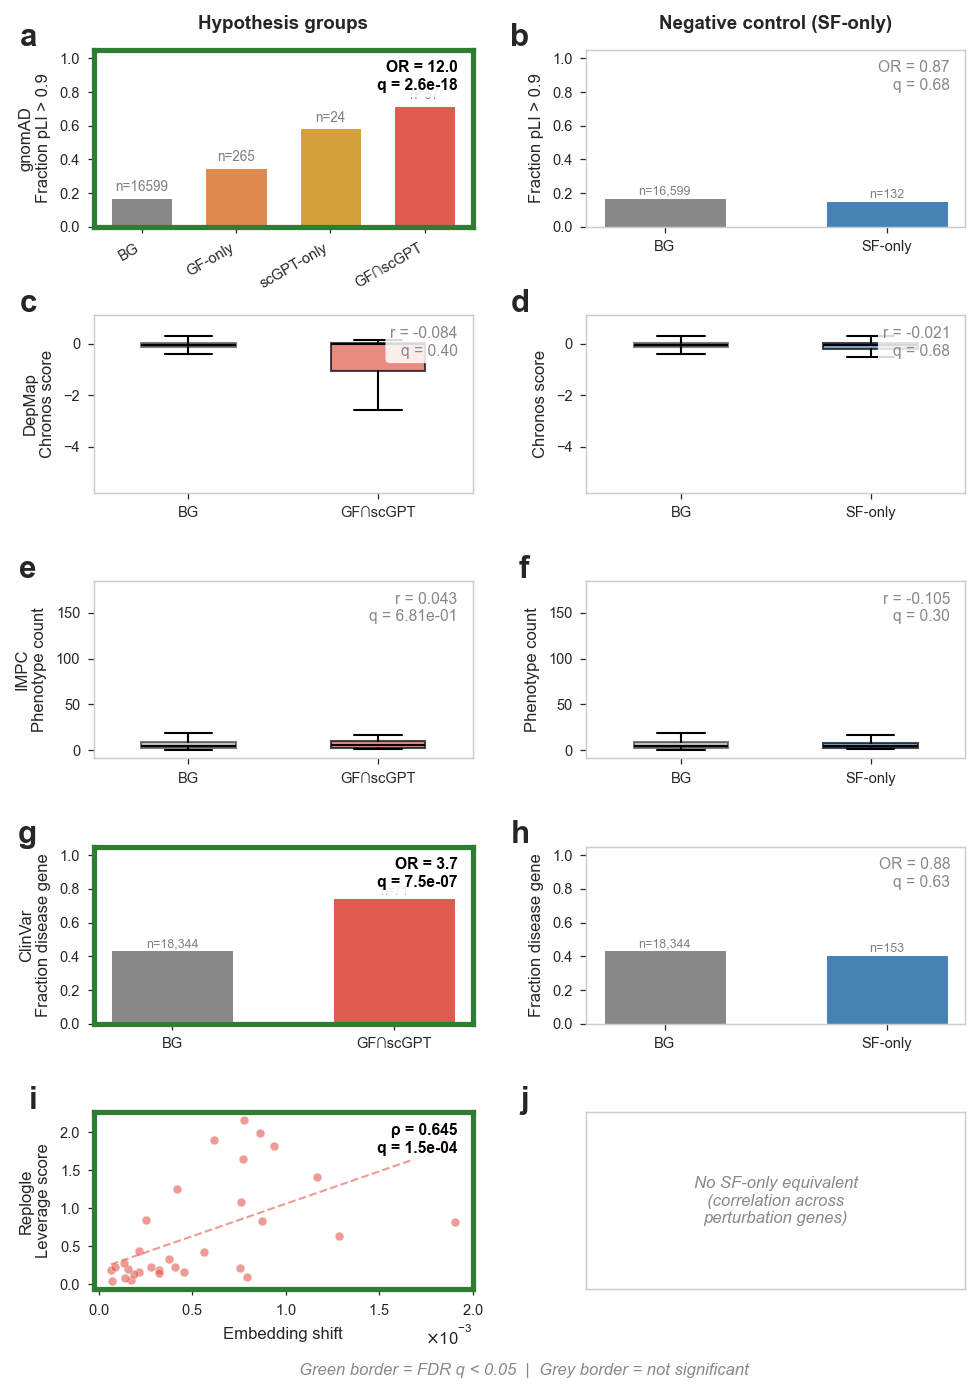

In [8]:
# Fig S5: External validation panel grid (5 rows × 2 columns)
#
# Framework: one primary test per external dataset, test type determined by
# data structure (Fisher for categorical, MWU for continuous, Spearman for
# paired correlation). Applied to shared outliers (hypothesis) and SF-only
# (negative control). gnomAD additionally includes GF-only and scGPT-only
# for the graded-enrichment argument.
#
import matplotlib.ticker as mticker
from scipy.stats import mannwhitneyu
# statsmodels not required — BH-FDR implemented directly below

# ── Statistical helper functions (using exact scipy implementations) ────

def manual_spearmanr(x, y):
    """Spearman correlation using scipy (exact t-distribution p-value)."""
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 5:
        return np.nan, 1.0
    rho, p = spearmanr(x, y)
    return rho, p

def manual_fisher_exact(a, b, c, d):
    """Two-sided Fisher exact test using scipy."""
    table = np.array([[a, b], [c, d]])
    OR, p = fisher_exact(table, alternative='two-sided')
    # Use Haldane-Anscombe correction for odds ratio (matches original)
    OR_ha = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
    return OR_ha, p

def manual_mwu(x, y):
    """Mann-Whitney U test using scipy, returns rank-biserial r and p."""
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    x, y = x[np.isfinite(x)], y[np.isfinite(y)]
    n1, n2 = len(x), len(y)
    if n1 < 2 or n2 < 2:
        return np.nan, 1.0
    U1, p = mannwhitneyu(x, y, alternative='two-sided')
    r_rb = 2 * U1 / (n1 * n2) - 1
    return r_rb, p

def bh_fdr(pvals):
    """Benjamini-Hochberg FDR correction."""
    pvals = np.array(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    pvals_sorted = pvals[order]
    fdr = np.empty(n)
    fdr[order[-1]] = pvals_sorted[-1]
    for i in range(n - 2, -1, -1):
        fdr[order[i]] = min(fdr[order[i + 1]], pvals_sorted[i] * n / (i + 1))
    return np.clip(fdr, 0, 1)

# ── Build test battery ──────────────────────────────────────────────────
all_results = []
bg_cm = cm[cm['outlier_set'] == 'neither']
bg_cmv = cmv[cmv['outlier_set'] == 'neither']

def fisher_pli(grp_label):
    sub = cm[cm['outlier_set'] == grp_label]
    sp = sub.dropna(subset=['pLI']); bp = bg_cm.dropna(subset=['pLI'])
    a = int((sp['pLI'] > 0.9).sum()); b = len(sp) - a
    c = int((bp['pLI'] > 0.9).sum()); d = len(bp) - c
    OR, p = manual_fisher_exact(a, b, c, d)
    return dict(source='gnomAD', test=f'pLI > 0.9 ({grp_label})',
                stat=OR, pval=p, n=a + b, label=grp_label)

def fisher_clinvar(grp_label):
    cg = cmv[cmv['outlier_set'] == grp_label]
    a = int(cg['disease_gene'].sum()); b = len(cg) - a
    c = int(bg_cmv['disease_gene'].sum()); d = len(bg_cmv) - c
    OR, p = manual_fisher_exact(a, b, c, d)
    return dict(source='ClinVar', test=f'Disease gene ({grp_label})',
                stat=OR, pval=p, n=a + b, label=grp_label)

def mwu_depmap(grp_label):
    sub = cm[cm['outlier_set'] == grp_label]
    r, p = manual_mwu(sub['mean_dep'].dropna().values, bg_cm['mean_dep'].dropna().values)
    return dict(source='DepMap', test=f'MWU Chronos ({grp_label})',
                stat=r, pval=p, n=len(sub['mean_dep'].dropna()), label=grp_label)

def mwu_impc(grp_label):
    sub = cm[cm['outlier_set'] == grp_label]
    si = sub['n_phenotypes'].dropna(); bi = bg_cm['n_phenotypes'].dropna()
    if len(si) < 2 or len(bi) < 2:
        return None
    r, p = manual_mwu(si.values, bi.values)
    return dict(source='IMPC', test=f'MWU phenotypes ({grp_label})',
                stat=r, pval=p, n=len(si), label=grp_label)

# Dataset 1: gnomAD pLI (Fisher) — shared + SF + single-model groups
for grp in ['GF\u2229scGPT', 'GF-only', 'scGPT-only', 'SF-only']:
    all_results.append(fisher_pli(grp))
# Dataset 2: DepMap Chronos (MWU) — shared + SF
all_results.append(mwu_depmap('GF\u2229scGPT'))
all_results.append(mwu_depmap('SF-only'))
# Dataset 3: IMPC phenotypes (MWU) — shared + SF (conditional)
res = mwu_impc('GF\u2229scGPT')
if res: all_results.append(res)
impc_sf_res = mwu_impc('SF-only')
if impc_sf_res: all_results.append(impc_sf_res)
# Dataset 4: ClinVar disease gene (Fisher) — shared + SF
all_results.append(fisher_clinvar('GF\u2229scGPT'))
all_results.append(fisher_clinvar('SF-only'))
# Dataset 5: Replogle perturb-seq (Spearman) — one correlation
rep_merge = perturb.merge(rep[['ensembl_id', 'mean leverage score']],
                          on='ensembl_id', how='inner')
rho_rep, p_rep = manual_spearmanr(rep_merge['mean_shift'], rep_merge['mean leverage score'])
all_results.append(dict(source='Replogle', test='Spearman shift vs leverage',
                        stat=rho_rep, pval=p_rep, n=len(rep_merge), label='Perturbation genes'))

# ── Compile and FDR-correct ─────────────────────────────────────────────
results_df = pd.DataFrame(all_results)
results_df['pval_fdr'] = bh_fdr(results_df['pval'].values)
results_df['sig'] = results_df['pval_fdr'] < 0.05

n_sig = results_df['sig'].sum()
print(f'{n_sig} / {len(results_df)} tests significant after BH-FDR correction.\n')
for _, row in results_df.sort_values('pval').iterrows():
    sig_mark = '\u2713' if row['sig'] else ' '
    print(f'  [{sig_mark}] {row["test"]:35s}  stat={row["stat"]:8.3f}  p={row["pval"]:.2e}  FDR={row["pval_fdr"]:.2e}')

# ── Visual helpers ──────────────────────────────────────────────────────

def get_result(source, label):
    mask = (results_df['source'] == source) & (results_df['label'] == label)
    if mask.sum() == 0: return None
    return results_df[mask].iloc[0]

SIG_BORDER = '#2E7D32'
NONSIG_BORDER = '#CCCCCC'

def set_sig_border(ax, significant):
    c = SIG_BORDER if significant else NONSIG_BORDER
    lw = 2.5 if significant else 0.7
    for spine in ax.spines.values():
        spine.set_edgecolor(c)
        spine.set_linewidth(lw)

def add_stat_annotation(ax, line1, line2, significant):
    color = 'black' if significant else NEUTRAL_COLOR
    weight = 'bold' if significant else 'normal'
    ax.text(0.96, 0.94, f'{line1}\n{line2}', transform=ax.transAxes, fontsize=7.5,
            ha='right', va='top', fontweight=weight, color=color,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='none'))

def empty_panel(ax, message='No equivalent test'):
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.5, message, transform=ax.transAxes, fontsize=8,
            ha='center', va='center', color=NEUTRAL_COLOR, fontstyle='italic')
    for spine in ax.spines.values():
        spine.set_edgecolor(NONSIG_BORDER); spine.set_linewidth(0.7)

# ── Data subsets ────────────────────────────────────────────────────────
shared = cm[cm['outlier_set'] == 'GF\u2229scGPT']
sf_only = cm[cm['outlier_set'] == 'SF-only']
gf_only = cm[cm['outlier_set'] == 'GF-only']
scgpt_only = cm[cm['outlier_set'] == 'scGPT-only']
shared_v = cmv[cmv['outlier_set'] == 'GF\u2229scGPT']
sf_only_v = cmv[cmv['outlier_set'] == 'SF-only']
GF_ONLY_COL = '#E08A4F'
SCGPT_ONLY_COL = '#D4A03C'

# ── 5\u00d72 panel grid ──────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 2, figsize=(7.0, 9.5))
fig.subplots_adjust(hspace=0.50, wspace=0.30, left=0.13, right=0.96,
                    top=0.94, bottom=0.07)
axes[0, 0].set_title('Hypothesis groups', fontsize=9, fontweight='bold', pad=10)
axes[0, 1].set_title('Negative control (SF-only)', fontsize=9, fontweight='bold', pad=10)

panel_labels = 'abcdefghij'
for i, ax in enumerate(axes.flat):
    ax.text(-0.15, 1.15, panel_labels[i], transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='right',
            fontfamily='sans-serif')

fig.text(0.54, 0.01,
         'Green border = FDR q < 0.05  |  Grey border = not significant',
         ha='center', fontsize=8, color=NEUTRAL_COLOR, fontstyle='italic')

# ── Row 0: gnomAD pLI > 0.9 (Fisher exact) ─────────────────────────────
ax = axes[0, 0]
groups_graded = [('BG', bg_cm, NEUTRAL_COLOR), ('GF-only', gf_only, GF_ONLY_COL),
                 ('scGPT-only', scgpt_only, SCGPT_ONLY_COL), ('GF\u2229scGPT', shared, GLITCH_COLOR)]
props, ns = [], []
for name, grp, col in groups_graded:
    pli = grp['pLI'].dropna(); props.append((pli > 0.9).mean()); ns.append(len(pli))
bars = ax.bar(range(4), props, color=[g[2] for g in groups_graded],
              edgecolor='white', linewidth=0.5, width=0.65)
ax.set_xticks(range(4))
ax.set_xticklabels([g[0] for g in groups_graded], fontsize=7, rotation=30, ha='right')
ax.set_ylabel('gnomAD\nFraction pLI > 0.9', fontsize=8); ax.set_ylim(0, 1.05)
ax.tick_params(axis='y', labelsize=7)
for ib, (b, nb) in enumerate(zip(bars, ns)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f'n={nb}', ha='center', va='bottom', fontsize=6.5, color='grey')
r_ = get_result('gnomAD', 'GF\u2229scGPT')
set_sig_border(ax, True)
add_stat_annotation(ax, f'OR = {r_["stat"]:.1f}', f'q = {r_["pval_fdr"]:.1e}', True)

ax = axes[0, 1]
bg_prop = (bg_cm['pLI'].dropna() > 0.9).mean()
sf_prop = (sf_only['pLI'].dropna() > 0.9).mean()
ax.bar([0, 1], [bg_prop, sf_prop], color=[NEUTRAL_COLOR, CONTROL_COLOR],
       edgecolor='white', linewidth=0.5, width=0.55)
ax.set_xticks([0, 1]); ax.set_xticklabels(['BG', 'SF-only'], fontsize=7)
ax.set_ylim(0, 1.05); ax.tick_params(axis='y', labelsize=7)
ax.set_ylabel('Fraction pLI > 0.9', fontsize=8)
ax.text(0, bg_prop+0.02, f'n={len(bg_cm["pLI"].dropna()):,}', ha='center', fontsize=6, color='grey')
ax.text(1, sf_prop+0.02, f'n={len(sf_only["pLI"].dropna())}', ha='center', fontsize=6, color='grey')
r_ = get_result('gnomAD', 'SF-only')
set_sig_border(ax, r_['sig'])
add_stat_annotation(ax, f'OR = {r_["stat"]:.2f}', f'q = {r_["pval_fdr"]:.2f}', r_['sig'])

# ── Row 1: DepMap CRISPR essentiality (MWU) ─────────────────────────────
dep_bg = bg_cm['mean_dep'].dropna()
ax = axes[1, 0]
dep_sh = shared['mean_dep'].dropna()
bp = ax.boxplot([dep_bg.values, dep_sh.values], widths=0.5, patch_artist=True,
                medianprops=dict(color='black', linewidth=1), flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgewidth=0))
bp['boxes'][0].set_facecolor(NEUTRAL_COLOR); bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor(GLITCH_COLOR); bp['boxes'][1].set_alpha(0.7)
ax.set_xticklabels(['BG', 'GF\u2229scGPT'], fontsize=7)
ax.set_ylabel('DepMap\nChronos score', fontsize=8); ax.tick_params(axis='y', labelsize=7)
r_ = get_result('DepMap', 'GF\u2229scGPT')
set_sig_border(ax, r_['sig'])
add_stat_annotation(ax, f'r = {r_["stat"]:.3f}', f'q = {r_["pval_fdr"]:.2f}', r_['sig'])

ax = axes[1, 1]
dep_sf = sf_only['mean_dep'].dropna()
bp = ax.boxplot([dep_bg.values, dep_sf.values], widths=0.5, patch_artist=True,
                medianprops=dict(color='black', linewidth=1), flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgewidth=0))
bp['boxes'][0].set_facecolor(NEUTRAL_COLOR); bp['boxes'][0].set_alpha(0.5)
bp['boxes'][1].set_facecolor(CONTROL_COLOR); bp['boxes'][1].set_alpha(0.7)
ax.set_xticklabels(['BG', 'SF-only'], fontsize=7)
ax.set_ylabel('Chronos score', fontsize=8); ax.tick_params(axis='y', labelsize=7)
r_ = get_result('DepMap', 'SF-only')
set_sig_border(ax, r_['sig'])
add_stat_annotation(ax, f'r = {r_["stat"]:.3f}', f'q = {r_["pval_fdr"]:.2f}', r_['sig'])

# ── Row 2: IMPC mouse knockout phenotypes (MWU) ─────────────────────────
impc_bg = bg_cm['n_phenotypes'].dropna()
ax = axes[2, 0]
impc_sh = shared['n_phenotypes'].dropna()
if len(impc_sh) >= 2:
    bp = ax.boxplot([impc_bg.values, impc_sh.values], widths=0.5, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1), flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgewidth=0))
    bp['boxes'][0].set_facecolor(NEUTRAL_COLOR); bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor(GLITCH_COLOR); bp['boxes'][1].set_alpha(0.7)
    ax.set_xticklabels(['BG', 'GF\u2229scGPT'], fontsize=7)
    r_ = get_result('IMPC', 'GF\u2229scGPT')
    if r_ is not None:
        set_sig_border(ax, r_['sig'])
        add_stat_annotation(ax, f'r = {r_["stat"]:.3f}', f'q = {r_["pval_fdr"]:.2e}', r_['sig'])
    else: set_sig_border(ax, False)
else: empty_panel(ax, 'Insufficient data')
ax.set_ylabel('IMPC\nPhenotype count', fontsize=8); ax.tick_params(axis='y', labelsize=7)

ax = axes[2, 1]
impc_sf = sf_only['n_phenotypes'].dropna()
if len(impc_sf) >= 2 and impc_sf_res is not None:
    bp = ax.boxplot([impc_bg.values, impc_sf.values], widths=0.5, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1), flierprops=dict(marker='o', markersize=2, alpha=0.3, markeredgewidth=0))
    bp['boxes'][0].set_facecolor(NEUTRAL_COLOR); bp['boxes'][0].set_alpha(0.5)
    bp['boxes'][1].set_facecolor(CONTROL_COLOR); bp['boxes'][1].set_alpha(0.7)
    ax.set_xticklabels(['BG', 'SF-only'], fontsize=7)
    r_ = get_result('IMPC', 'SF-only')
    if r_ is not None:
        set_sig_border(ax, r_['sig'])
        add_stat_annotation(ax, f'r = {r_["stat"]:.3f}', f'q = {r_["pval_fdr"]:.2f}', r_['sig'])
    else: set_sig_border(ax, False)
else: empty_panel(ax, 'Insufficient data\n(too few SF-only genes\nwith IMPC annotations)')
ax.set_ylabel('Phenotype count', fontsize=8); ax.tick_params(axis='y', labelsize=7)

# ── Row 3: ClinVar disease association (Fisher exact) ───────────────────
ax = axes[3, 0]
sh_dg = shared_v['disease_gene'].mean(); bg_dg = bg_cmv['disease_gene'].mean()
ax.bar([0, 1], [bg_dg, sh_dg], color=[NEUTRAL_COLOR, GLITCH_COLOR],
       edgecolor='white', linewidth=0.5, width=0.55)
ax.set_xticks([0, 1]); ax.set_xticklabels(['BG', 'GF\u2229scGPT'], fontsize=7)
ax.set_ylabel('ClinVar\nFraction disease gene', fontsize=8); ax.set_ylim(0, 1.05)
ax.tick_params(axis='y', labelsize=7)
ax.text(0, bg_dg+0.02, f'n={len(bg_cmv):,}', ha='center', fontsize=6, color='grey')
ax.text(1, sh_dg+0.02, f'n={len(shared_v)}', ha='center', fontsize=6, color='grey')
r_ = get_result('ClinVar', 'GF\u2229scGPT')
set_sig_border(ax, r_['sig'])
add_stat_annotation(ax, f'OR = {r_["stat"]:.1f}', f'q = {r_["pval_fdr"]:.1e}', r_['sig'])

ax = axes[3, 1]
sf_dg = sf_only_v['disease_gene'].mean()
ax.bar([0, 1], [bg_dg, sf_dg], color=[NEUTRAL_COLOR, CONTROL_COLOR],
       edgecolor='white', linewidth=0.5, width=0.55)
ax.set_xticks([0, 1]); ax.set_xticklabels(['BG', 'SF-only'], fontsize=7)
ax.set_ylabel('Fraction disease gene', fontsize=8); ax.set_ylim(0, 1.05)
ax.tick_params(axis='y', labelsize=7)
ax.text(0, bg_dg+0.02, f'n={len(bg_cmv):,}', ha='center', fontsize=6, color='grey')
ax.text(1, sf_dg+0.02, f'n={len(sf_only_v)}', ha='center', fontsize=6, color='grey')
r_ = get_result('ClinVar', 'SF-only')
set_sig_border(ax, r_['sig'])
add_stat_annotation(ax, f'OR = {r_["stat"]:.2f}', f'q = {r_["pval_fdr"]:.2f}', r_['sig'])

# ── Row 4: Replogle perturb-seq (Spearman) ──────────────────────────────
ax = axes[4, 0]
ax.scatter(rep_merge['mean_shift'], rep_merge['mean leverage score'],
           s=18, c=GLITCH_COLOR, alpha=0.6, edgecolors='white', linewidth=0.3)
z = np.polyfit(rep_merge['mean_shift'], rep_merge['mean leverage score'], 1)
xline = np.linspace(rep_merge['mean_shift'].min(), rep_merge['mean_shift'].max(), 100)
ax.plot(xline, np.polyval(z, xline), '--', color=GLITCH_COLOR, alpha=0.6, linewidth=1)
ax.set_ylabel('Replogle\nLeverage score', fontsize=8)
ax.set_xlabel('Embedding shift', fontsize=8)
ax.tick_params(axis='both', labelsize=7)
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='x', style='scientific', scilimits=(0, 0))
r_ = get_result('Replogle', 'Perturbation genes')
set_sig_border(ax, r_['sig'])
add_stat_annotation(ax, f'\u03c1 = {r_["stat"]:.3f}', f'q = {r_["pval_fdr"]:.1e}', r_['sig'])

ax = axes[4, 1]
empty_panel(ax, 'No SF-only equivalent\n(correlation across\nperturbation genes)')

# ── Save ────────────────────────────────────────────────────────────────
save_fig(fig, 'figS5_validation_summary')
plt.show()
